In [1]:
# Imports
from math import ceil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy
from numpy.typing import NDArray
from scipy.interpolate import RegularGridInterpolator

from synaptus import get_envelope, log_image, nextpow2, plot_us_image

In [2]:
# Paths
example_data_path = Path().resolve().parent.parent / "datasets" / "LineScan2D_WireTargets.mat"

In [3]:
# Parameters
f_low = 0.4e6  # Lower cutoff freq., transducer band
f_high = 2.5e6  # Upper cutoff freq., transducer band
upsampling_factor = 4

In [4]:
# Load data
example_data = scipy.io.loadmat(example_data_path)
ptx = example_data["ptx"]  # 2D ultrasound data p(t,x)
fs = example_data["fs"].item()  # Sampling frequency
xstep = example_data["xStep"].item()  # Spatial step size (x-axis)
sound_vel = example_data["cc"].item()  # Sound velocity
t_delay = example_data["tDelay"].item()  # Pulse recording delay

nt, nx = ptx.shape


In [5]:
# Define helper functions


def get_kz_matrix(OMEGA, KX, sound_vel):
    """Calculate wavenumber kz for every combination of omega and kx"""
    KZ2 = ((2 / sound_vel) ** 2) * (OMEGA**2) - KX**2
    real_wave_index = KZ2 >= 0
    KZ = np.sqrt(KZ2 * real_wave_index)
    return KZ, real_wave_index


def get_phase_shift_matrix(KZ, dz):
    """Calculate incremental phase shift in z direction"""
    return np.exp(1j * KZ * dz)


def time_shift_to_zero(Pokx, t_delay, OMEGA):
    return Pokx * np.exp(-1j * OMEGA * t_delay)


def z_shift_to_measurement_start(Pokx, KZ, t_delay, sound_vel):
    z_start = t_delay * (sound_vel / 2)
    return Pokx * np.exp(1j * KZ * z_start)

In [6]:
# Static variables related to Z axis
z_start = t_delay * (sound_vel / 2)
z_end = z_start + (nt / fs) * (sound_vel / 2)
dz = (sound_vel / 2) / (f_high - f_low)  # Z resolution
nz = ceil((z_end - z_start) / dz)  # Number of z lines in focused im.

# Make time/space coodinate variables
nn = np.arange(nt)
tt = t_delay + nn / fs
xx = np.arange(nx) * xstep
zz = z_start + np.arange(nz) * dz

#  Make spectrum coordinate vectors
nfft_t = nextpow2(nt) * upsampling_factor
nfft_x = nextpow2(nx)
omega = np.fft.fftshift(np.fft.fftfreq(nfft_t, 1 / fs)) * (2 * np.pi)
# omega_band_ind = (omega <= -2 * np.pi * f_low) & (omega >= -2 * np.pi * f_high)
omega_band_ind = (omega >= 2 * np.pi * f_low) & (omega <= 2 * np.pi * f_high)
kx = np.fft.fftshift(np.fft.fftfreq(nfft_x, xstep)) * (2 * np.pi)

# Create meshgrid coordinate matrices
OMEGA, KX = np.meshgrid(omega, kx, indexing="ij")


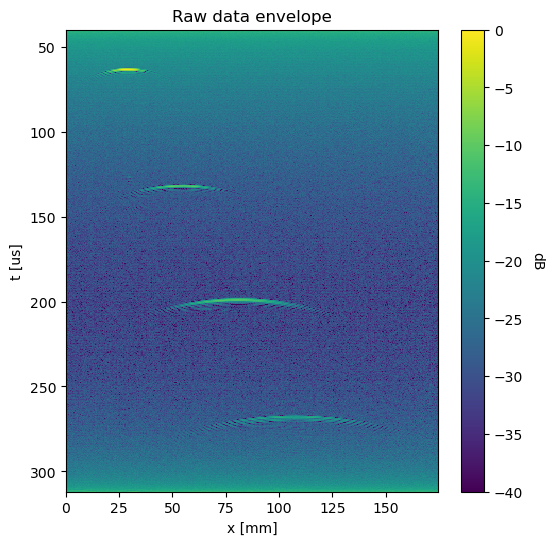

In [7]:
# Plot raw data
plot_us_image(
    get_envelope(ptx),
    x_val=xx * 1e3,
    y_val=tt * 1e6,
    x_label="x [mm]",
    y_label="t [us]",
    title="Raw data envelope",
    min_db=-40,
    figsize=(6, 6),
)


In [8]:
# 2D Fourier transform
Pokx = np.fft.fftshift(np.fft.fftn(ptx, s=(nfft_t, nfft_x)))

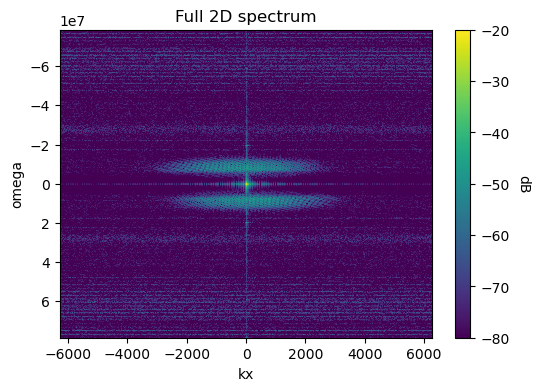

In [9]:
# Plot
plot_us_image(
    Pokx,
    x_val=kx,
    y_val=omega,
    x_label="kx",
    y_label="omega",
    title="Full 2D spectrum",
    min_db=-80,
    max_db=-20,
)

In [10]:
# %% Cut out part of spectrum corresponding to transducer freq. band, neg. omega
Pokx_band = Pokx[omega_band_ind, :]

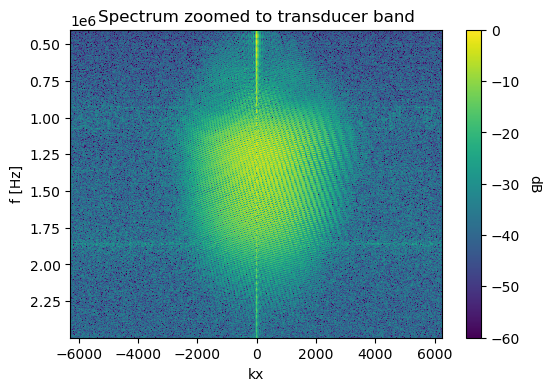

In [11]:
# Plot
plot_us_image(
    Pokx_band,
    x_val=kx,
    y_val=omega[omega_band_ind] / (2 * np.pi),
    x_label="kx",
    y_label="f [Hz]",
    title="Spectrum zoomed to transducer band",
)


In [12]:
# Calculate KZ
KZ, real_wave_index = get_kz_matrix(OMEGA[omega_band_ind], KX[omega_band_ind], sound_vel)


In [13]:
# Time shift to t=0
Pokx_t0 = time_shift_to_zero(Pokx_band, t_delay, OMEGA[omega_band_ind])
ptx_t0 = np.fft.ifftn(np.fft.ifftshift(Pokx_t0, axes=(1,)))
ptx_t0 = ptx_t0[0 : round(nt * (f_high - f_low) / (fs / 2)), 0:nx]

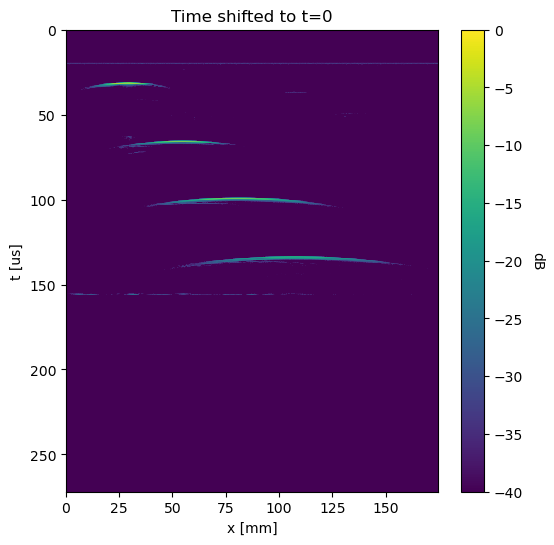

In [16]:
# Plot wavefield time shifted to t=0
plot_us_image(
    ptx_t0,
    x_val=xx * 1e3,
    y_val=(tt - t_delay) * 1e6,
    x_label="x [mm]",
    y_label="t [us]",
    title="Time shifted to t=0",
    min_db=-40,
    figsize=(6, 6),
)

# Interpolating from $(k_x,k_z)$ to $\omega$ 


In [17]:
nfft_z = nextpow2(nt * (f_high - f_low) / (fs / 2))
# nfft_z = nextpow2(nt * (f_high - f_low) / fs)  # Correct not to use fs/2?
# nfft_z = nextpow2(nt * (f_high - f_low) / (fs / 2)) * 2

kzs = (2 * np.pi) / dz
kz = (2 * np.pi * f_low) / (sound_vel / 2) + np.arange(nfft_z) * (kzs / nfft_z)


In [18]:
# Create meshgrid coordinate matrices
KZ_interp, KX_interp = np.meshgrid(kz, kx, indexing="ij")
OMEGA_interp = np.sqrt(KZ_interp**2 + KX_interp**2) * (sound_vel / 2)

In [19]:
# Create amplitude scaling factor
Akzkx = 1 / (1 + (KX_interp**2) / KZ_interp**2)
# Akzkx(isnan(Akzkx)) = 1

Interpolation, see
https://docs.scipy.org/doc/scipy/tutorial/interpolate/1D.html#tutorial-interpolate-1dsection

PCHIP and cubic interpolators are probably the best options (other than straight linear
interpolation).

For support for complex numbers, the
"[RegularGridInterpolator](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.RegularGridInterpolator.html)"
is maybe the best option?

In [20]:
# Create interpolator object
interpolator = RegularGridInterpolator(
    points=(omega[omega_band_ind], kx),
    values=Pokx_t0,
    bounds_error=False,
    fill_value=0,
    method="linear",
)

In [21]:
Pkzkx = interpolator((OMEGA_interp, KX_interp)) * Akzkx

/home/mha114/Dropbox/Matlab/synaptus_git/synaptus/python/synaptus/utils.py:37: RuntimeWarning: divide by zero encountered in log10
  return 20 * np.log10(im / np.max(im))


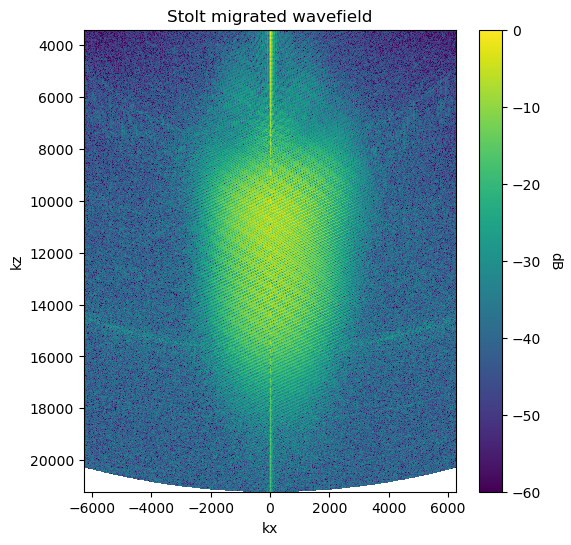

In [22]:
# Plot interpolated wavefield time P(kz,kx,t=0)
plot_us_image(
    Pkzkx,
    x_val=kx,
    y_val=kz,
    x_label="kx",
    y_label="kz",
    title="Stolt migrated wavefield",
    min_db=-60,
    figsize=(6, 6),
)

In [23]:
pzx = np.fft.ifftn(np.fft.ifftshift(Pkzkx, axes=(1,)))

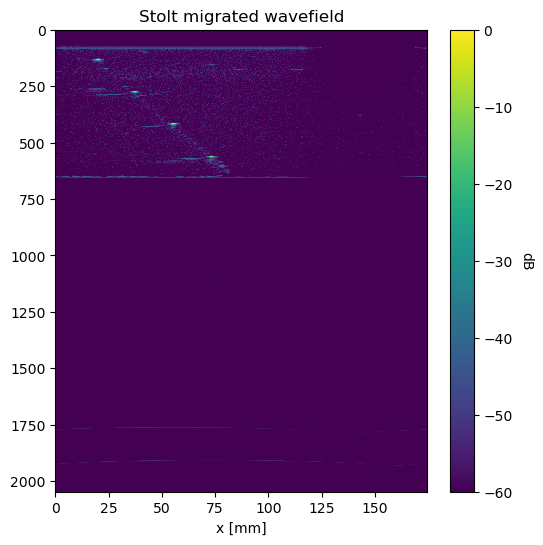

In [24]:
# Plot interpolated wavefield time P(z,x,t=0)
plot_us_image(
    pzx[:, :],
    x_val=xx * 1e3,
    # y_val=np.arange(nfft) * 1e3,
    x_label="x [mm]",
    # y_label="z [mm]",
    title="Stolt migrated wavefield",
    min_db=-60,
    figsize=(6, 6),
)

In [25]:
# Shift wavefield to measurement start
Pkzkx_shifted = Pkzkx * np.exp(1j * KZ_interp * z_start)
pzx_shifted = np.fft.ifftn(np.fft.ifftshift(Pkzkx_shifted, axes=(1,)))

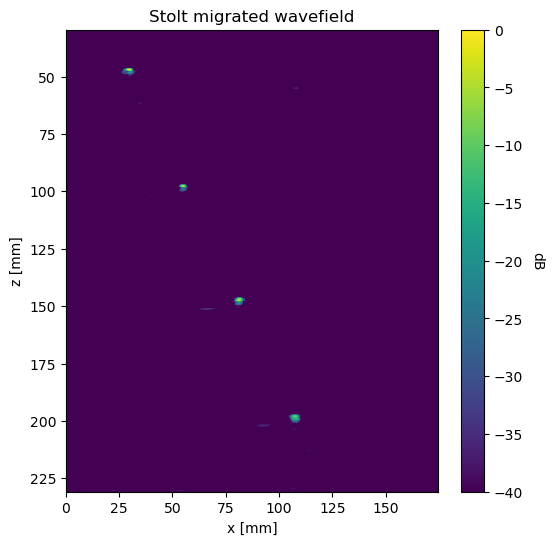

In [26]:
# Plot shifted (and cropped) wavefield
plot_us_image(
    pzx_shifted[:nz, :nx],
    x_val=xx * 1e3,
    y_val=zz * 1e3,
    x_label="x [mm]",
    y_label="z [mm]",
    title="Stolt migrated wavefield",
    min_db=-40,
    figsize=(6, 6),
)